In [3]:
import numpy as np
import pandas as pd


from src.split import BucketSplitter
from src.srm import check_srm, print_srm_report
from src.analysis import analyze_experiment, print_analysis_report
from src.aa_test import run_aa_tests, plot_aa_pvalues


In [4]:
def generate_ab_data(n_users: int = 100_000, pre_post_corr: float = 0.6, seed: int = 42) -> pd.DataFrame:

    rng = np.random.default_rng(seed)
    user_id = np.arange(n_users)
    
    # Страты
    platform = rng.choice(['ios', 'android', 'web'], size=n_users, p=[0.4, 0.45, 0.15])
    country = rng.choice(['RU', 'KZ', 'BY', 'UZ'], size=n_users, p=[0.7, 0.15, 0.1, 0.05])
    segment = rng.choice(['new', 'old'], size=n_users, p=[0.3, 0.7])
    

    log_pre = rng.normal(loc=1.5, scale=0.8, size=n_users)
    
    noise = rng.normal(0, 1, size=n_users)
    
    log_pre_std = (log_pre - log_pre.mean()) / log_pre.std()

    log_post_std = (pre_post_corr * log_pre_std + np.sqrt(1 - pre_post_corr**2) * noise)
    
    log_post = log_post_std * log_pre.std() + log_pre.mean()
    
    pre_metric = np.exp(log_pre)
    post_metric = np.exp(log_post)
    
    df = pd.DataFrame({
        'user_id': user_id,
        'platform': platform,
        'country': country,
        'segment': segment,
        'pre_metric': pre_metric,
        'post_metric': post_metric
    })
    
    return df

In [5]:
df = generate_ab_data()

In [6]:
splitter = BucketSplitter(salt="test_exp")

df_split = splitter.split(df, stratify_by=["platform", "country"])

df_split

,user_id,platform,country,segment,pre_metric,post_metric,group,bucket
0,0,android,BY,old,9.549197,3.613638,control,497
1,1,android,BY,old,6.420027,21.612214,treatment,899
2,2,web,RU,old,3.735409,2.803492,treatment,863
3,3,android,RU,old,0.616127,0.787866,control,466
4,4,ios,KZ,old,10.177308,8.796768,control,266
...,...,...,...,...,...,...,...,...
99995,99995,ios,RU,old,0.944019,1.170932,treatment,578
99996,99996,android,RU,new,1.957014,6.014542,control,236
99997,99997,android,RU,old,4.013743,9.017195,treatment,816
99998,99998,ios,RU,new,1.605542,0.908839,treatment,690


In [ ]:
result = check_srm(df_split)
print_srm_report(result)

SRM Check Report: OK — no SRM
p-value:          0.949571
alpha:            0.001
Всего пользователей: 100,000


Доли групп:
control      | факт: 50.01% (50,010)  |  ожидалось: 50.00% (50,000)
treatment    | факт: 49.99% (49,990)  |  ожидалось: 50.00% (50,000)


In [ ]:
result = analyze_experiment(df_split)
print_analysis_report(result)

A/B Test Analysis Report: Есть статистически значимый отрицательный эффект
Control mean:       1.6640

Treatment mean:     1.6328
Absolute uplift:    -0.0312

Relative uplift:    -1.87%
p-value:            0.023307

95% CI:            [-0.0581, -0.0042]
n control:          50,010
n treatment:        49,990


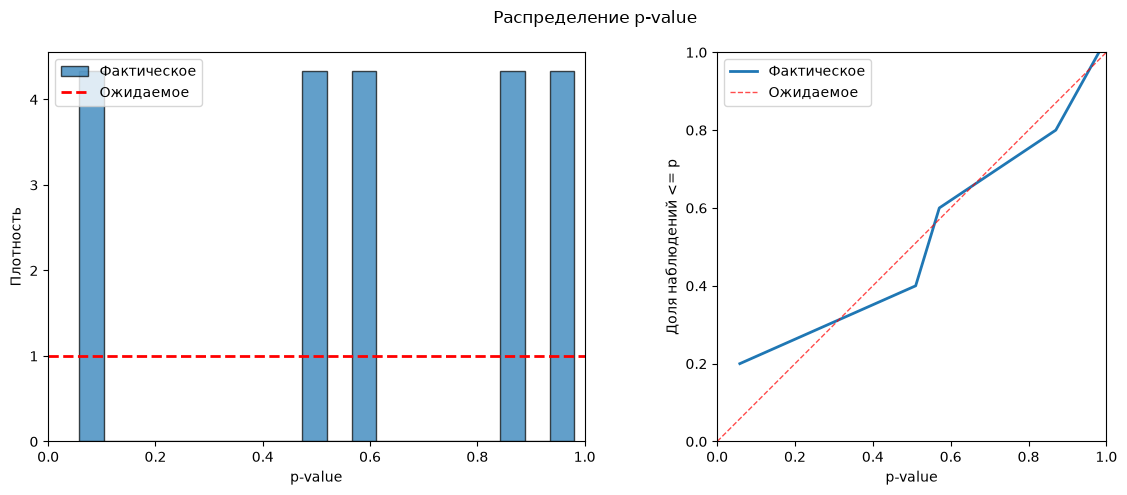

In [ ]:
aa = run_aa_tests(df, 5)
plot_aa_pvalues(aa)